# Predicción de la duración de estancia hospitalaria

**Proyecto**: Fundamentos de Ciencia de Datos 2025-2  
**Autor**: Thomas GIRAULT  

---

## Contexto

Hoy en día los hospitales enfrentan un gran reto: saber con antelación cuánto tiempo ocupará cada paciente una cama. Predecir la duración de la estancia no solo ayuda a mejorar la atención, sino también a organizar los recursos, reducir esperas y evitar sobrecargas en épocas de alta demanda.  

En este proyecto vamos a intentar estimar la duración de la hospitalización de un paciente a partir de información básica: sexo, índice de masa corporal (IMC), historial médico, número de ingresos previos y varios datos clínicos como indicadores de laboratorio. La idea es construir un modelo que pueda apoyar la **planificación hospitalaria** y la **gestión de camas disponibles**.  

---

## Dataset

Trabajaremos con el dataset **“Hospital Length of Stay”** publicado por Microsoft en Kaggle:  
https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft  

En el repositorio se incluirán los datos originales (tal cual descargados) y también una versión filtrada y adaptada para nuestro análisis.  

---

## Objetivos

- Explorar y entender los datos para identificar las variables más útiles.  
- Hacer un análisis descriptivo con estadísticas y visualizaciones (distribuciones, relaciones entre variables, etc.).  
- Detectar valores atípicos y decidir si se eliminan o si tienen sentido clínico.  
- Preparar una base sólida para la siguiente fase, donde se entrenará un modelo de predicción de la duración de la estancia.  

---

## Dependencias y librerías

El análisis se hará principalmente con:  
- `numpy` y `pandas` para manipulación de datos,  
- `matplotlib` y `seaborn` para visualización,  
- opcionalmente `scipy` u otras librerías si hacen falta para estadística o detección de outliers.  

Instalación rápida:  

In [ ]:
!pip install numpy pandas matplotlib seaborn scipy

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# I - Le choix des variables caractéristiques

La première étape de mon projet a été de filtrer cet énorme dataset, contenant 100k échantillons et un total de 28 caractéristiques. Ce sont précisément ces caractéristiques qui nous intéressent à ce stade. En effet, comment pouvons-nous juger si une variable est pertinente à garder, à utiliser pour notre étude ou même pour en construire de nouvelles ?

À la fin de cette étape, je dois conserver au minimum 6 caractéristiques, dont 3 continues et 3 discrètes.

## Présentation des variables dans leur globalité

Avant d’expliquer les variables que j’ai choisies, je vais présenter rapidement l’ensemble des variables disponibles dans le dataset. Il y en a 28 au total. Voici la liste complète :  

<p align="center">
    <img src="../datos/data_explained.png" alt="Explicación de los datos" width="900">
</p>

On retrouve par exemple **l’ID**, la **date d’arrivée** et la **date de sortie** qui, comme on peut s’y attendre, ne seront pas utiles pour notre étude.  

En revanche, plusieurs groupes de variables sont plus intéressants :  

- **Index 5 à 15 : comorbidités ICD-9**  
  Ce sont des variables binaires (1 = présence de la comorbidité, 0 = absence).  
  Elles sont particulièrement pertinentes, car l’ICD est un standard médical largement utilisé dans le codage des diagnostics. Ces comorbidités sont connues pour avoir un impact direct sur la durée de séjour.  

- **Index 16 à 21 : mesures sanguines**  
  On retrouve ici des variables continues comme l’hématocrite, la créatinine ou encore le sodium.  
  Ces indicateurs biologiques sont intéressants car ils permettent de détecter des anomalies dans le sang et reflètent l’état de santé du patient.  

- **Mesures physiologiques**  
  On dispose également du **BMI**, du **pouls** et de la **fréquence respiratoire**, trois variables classiques en suivi clinique.  

- **Comorbidités non-ICD**  
  Enfin, une variable supplémentaire indique le nombre de comorbidités non référencées dans l’ICD. C’est un entier allant de 0 à 10.  

Face à une telle quantité d’informations, il est difficile de savoir où concentrer l’attention. Les données sanguines, par exemple, sont très intéressantes, mais elles occupent déjà six variables, ce qui ne laisserait pas de place à d’autres dimensions.  
Notre professeur nous a donc conseillé de regarder du côté de la littérature scientifique. J’y ai consacré une bonne journée, et voici le résumé de mes recherches.

## Ce que dit la littérature

D’après [cette thèse](https://theses.hal.science/tel-04053390/document), les caractéristiques les plus importantes pour prédire la durée de séjour sont :  
- l’âge,  
- les diagnostics principaux et secondaires (donc les comorbidités),  
- le type d’admission,  
- et enfin l’évolution du patient pendant le séjour.  

Dans mon dataset, je ne dispose pas de toutes ces informations, mais seulement du nombre de diagnostics principaux et secondaires. J’ai donc choisi de sommer les comorbidités de l’index 5 à 15 afin de créer un score global basé sur l’ICD-9. J’ai aussi retenu la variable qui correspond au nombre de comorbidités secondaires non codées en ICD comme seconde caractéristique discrète. J’ai d’ailleurs vu sur Kaggle que certains conseillaient fortement cette approche, et qu’elle donnait de bons résultats dans les modèles.

Ensuite, j’ai décidé de garder le **BMI**, car la littérature montre une forte association avec la durée de séjour à l’hôpital. Les patients obèses sévères ou au contraire dénutris (BMI bas) ont en général des séjours plus longs. Plusieurs études (chirurgie cardiaque, orthopédie, soins intensifs) confirment une relation en U : un BMI trop bas ou trop élevé est lié à une hospitalisation prolongée. Voici quelques références :  

- [Nutrition support in critically ill patients](https://aspenjournals.onlinelibrary.wiley.com/doi/10.1177/088453360001500405)  
- [Obesity and postoperative complications in cardiac surgery](https://pubmed.ncbi.nlm.nih.gov/15681111/)  
- [Impact of body mass index on hospital stay in intensive care patients](https://pubmed.ncbi.nlm.nih.gov/30685103/)  

De la même manière, j’ai retenu la **fréquence respiratoire**, qui est un indicateur clinique reconnu et largement utilisé pour prédire la sévérité des cas et donc la durée du séjour.

En revanche, le **pouls** m’a étonné. D’après mes recherches, il semble avoir beaucoup moins d’impact sur la durée de séjour. Un rythme cardiaque normal au repos varie entre 60 bpm et 100 bpm, et il existe naturellement des variations physiologiques selon les individus (certains battent à 50, d’autres à 90). Cela ne veut pas forcément dire quelque chose de pertinent pour la durée d’hospitalisation. De plus, je n’ai trouvé aucune étude robuste l’utilisant comme prédicteur direct, donc je décide de le mettre de côté.

À côté de ça, j’ai ajouté la variable **rcount**, qui compte le nombre de fois qu’un patient a été réadmis dans les 180 derniers jours. Cette valeur va de 0 à 5+, ce qui n’est pas très pratique (un patient 5+ peut être revenu 5 fois comme 15 fois). Mais aux États-Unis, les contraintes de confidentialité empêchent de donner une valeur exacte au-delà de 5, car cela pourrait rendre certains patients identifiables.

Enfin, j’ai choisi d’ajouter le **genre** du patient, qui est une variable catégorielle et que je transformerai par la suite en variable discrète.  


## Le cas des variables sanguines

D’après la littérature, les deux variables biologiques les plus souvent utilisées pour prédire la durée de séjour sont celles liées à la fonction rénale : la **créatinine** et le **BUN (blood urea nitrogen)**. Elles sont considérées comme de bons indicateurs en soins intensifs, car elles traduisent directement l’état de la fonction rénale, très lié à la gravité et donc à la durée du séjour. Ces variables semblent plus pertinentes que d’autres comme le glucose ou le sodium, par exemple.

## Récapitulatif des variables choisies

| Variable                        | Type       | Définition                                         |
|---------------------------------|------------|----------------------------------------------------|
| BMI                             | Continue   | Indice de masse corporelle                         |
| Fréquence respiratoire           | Continue   | Nombre de respirations par minute                  |
| Creatinine                      | Continue   | Valeur moyenne de créatinine (mg/dL)               |
| Blood Urea Nitrogen (BUN)       | Continue   | Taux d’urée sanguine, indicateur de fonction rénale|
| Gender                          | Discrète   | Sexe du patient (M/F)                              |
| Readmission count (Rcount)      | Discrète   | Nombre de réadmissions (0 à 5+)                    |
| Comorbidités ICD-9 (somme)      | Discrète   | Nombre de comorbidités principales ICD-9           |
| Secondary Diagnoses ICD-9       | Discrète   | Nombre de diagnostics secondaires codés ICD-9      |

### Variable cible

| Variable   | Type  | Définition                         |
|------------|-------|------------------------------------|
| LOS        | Cible | Durée du séjour à l’hôpital (jours)|


# II - Mise en place du nouveau dataset et modiication

Le tableau étant énorme (100K muestraset et 28 caracétérique), le meillleur moyen de générer un nouveau dataset, nétoyer, et plus léger est de le faire via un script. J'ai donc mis en place un script pour récupérer les variables qui m'intéresse et en crée des nouvelles.

In [7]:
# archivos
input_file = "../datos/LengthOfStay.csv"
output_file = "../datos/LengthOfStay_filtered.csv"

# columnas que queremos guardar
cols_to_keep = [
    "rcount", 
    "gender",
    "bloodureanitro",
    "creatinine", 
    "bmi", 
    "respiration", 
    "secondarydiagnosisnonicd9", 
    "lengthofstay"
]

# columnas icd-9 principales
icd9_cols = [
    "dialysisrenalendstage","asthma","irondef","pneum","substancedependence",
    "psychologicaldisordermajor","depress","psychother","fibrosisandother",
    "malnutrition","hemo"
]

# si el archivo filtrado no existe lo creamos
if not os.path.exists(output_file):
    df = pd.read_csv(input_file)
    df["icd9_comorbidity_sum"] = df[icd9_cols].sum(axis=1)
    df_filtered = df[cols_to_keep + ["icd9_comorbidity_sum"]]
    df_filtered.to_csv(output_file, index=False)
    print(f"guardado como {output_file}")
else:
    print("el archivo filtrado ya existe, cargando...")
    df_filtered = pd.read_csv(output_file)

print("\nInformación general:")
df.info()

# mostrar estadisticas basicas
print("\nresumen estadistico del dataset filtrado:\n")
display(df_filtered.describe(include="all"))

# mostrar primeras filas
print("\nprimeras filas del dataset filtrado:\n")
display(df_filtered.head())

print("\nValores nulos por columna:")
print(df_filtered.isnull().sum())

el archivo filtrado ya existe, cargando...

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosis

,rcount,gender,bloodureanitro,creatinine,bmi,respiration,secondarydiagnosisnonicd9,lengthofstay,icd9_comorbidity_sum
count,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
unique,6,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,55031,57643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,14.097185,1.099350,29.805759,6.493768,2.123310,4.00103,0.743500
std,NaN,NaN,12.952454,0.200262,2.003769,0.568473,2.050641,2.36031,1.097406
min,NaN,NaN,1.000000,0.219770,21.992683,0.200000,0.000000,1.00000,0.000000
25%,NaN,NaN,11.000000,0.964720,28.454235,6.500000,1.000000,2.00000,0.000000
50%,NaN,NaN,12.000000,1.098764,29.807516,6.500000,1.000000,4.00000,0.000000
75%,NaN,NaN,14.000000,1.234867,31.156885,6.500000,3.000000,6.00000,1.000000



primeras filas del dataset filtrado:



,rcount,gender,bloodureanitro,creatinine,bmi,respiration,secondarydiagnosisnonicd9,lengthofstay,icd9_comorbidity_sum
0,0,F,12.0,1.390722,30.432418,6.5,4,3,0
1,5+,F,8.0,0.943164,28.460516,6.5,1,7,0
2,1,F,12.0,1.065750,28.843812,6.5,2,3,0
3,0,F,12.0,0.906862,27.959007,6.5,1,1,0
4,0,F,11.5,1.242854,30.258927,5.6,2,4,2



Valores nulos por columna:
rcount                       0
gender                       0
bloodureanitro               0
creatinine                   0
bmi                          0
respiration                  0
secondarydiagnosisnonicd9    0
lengthofstay                 0
icd9_comorbidity_sum         0
dtype: int64


# III - Analyse et exploration des données

Dans cette partie, nous allons effectuer une première analyse des variables que nous disposons dans notre nouveau dataset. Nous allons effectué des histogrammes, des boxplot, des matrice de correlation, .... (developpe un peu)

Cela permettras de visulaiser les variables de trouver des relations entre elles, analyser la distrubtion   

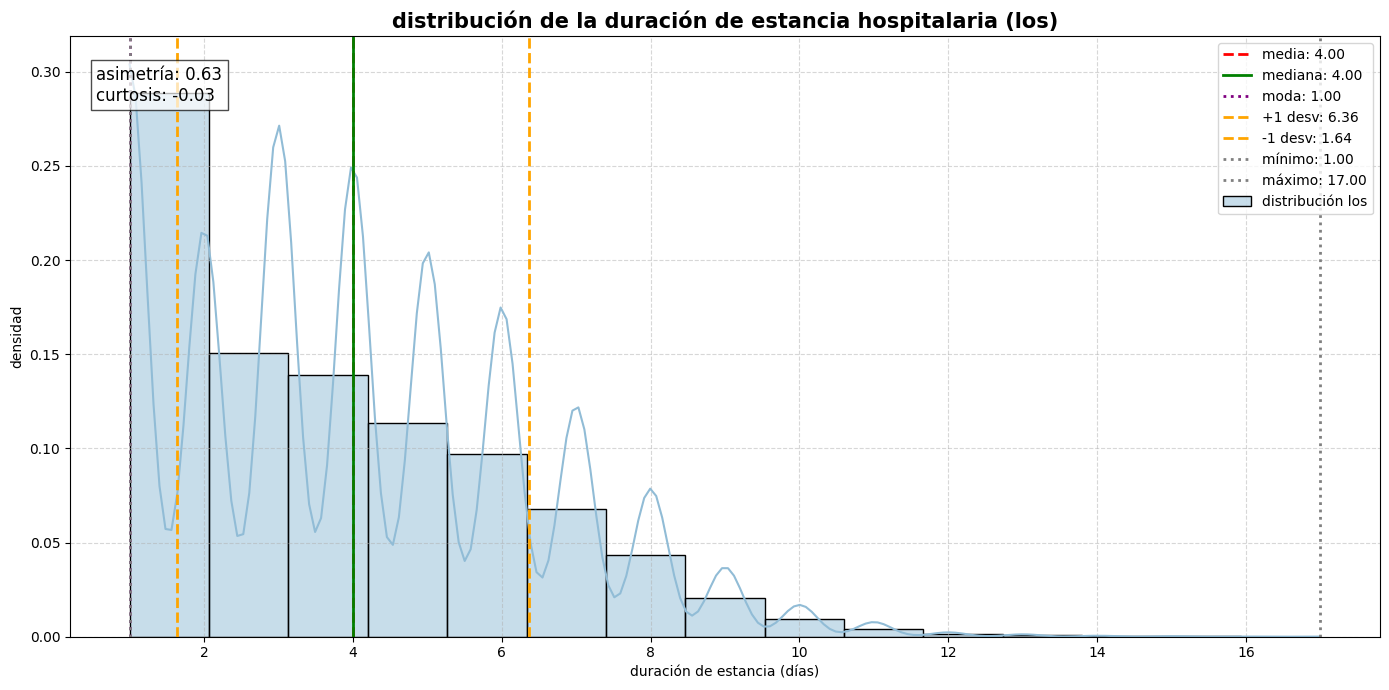

In [13]:
# extraer la variable de interés
los = df_filtered['lengthofstay'].dropna().values

# medidas descriptivas
media = np.mean(los)  # promedio de la estancia
mediana = np.median(los)  # valor central
moda = stats.mode(los, keepdims=True).mode[0]  # valor más frecuente
minimo = np.min(los)  # valor mínimo
maximo = np.max(los)  # valor máximo
desviacion = np.std(los)  # dispersión típica
asimetria = stats.skew(los)  # asimetría de la distribución
curtosis = stats.kurtosis(los)  # curtosis de la distribución

plt.figure(figsize=(14, 7))
sns.histplot(los, bins=15, kde=True, color="#91BCD6", stat="density", label="distribución los")

# líneas de referencia
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'moda: {moda:.2f}')
plt.axvline(media + desviacion, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media+desviacion):.2f}')
plt.axvline(media - desviacion, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media-desviacion):.2f}')
plt.axvline(minimo, color='grey', linestyle=':', linewidth=2, label=f'mínimo: {minimo:.2f}')
plt.axvline(maximo, color='grey', linestyle=':', linewidth=2, label=f'máximo: {maximo:.2f}')

# caja de texto con asimetría y curtosis
plt.text(0.02, 0.95, f'asimetría: {asimetria:.2f}\ncurtosis: {curtosis:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("distribución de la duración de estancia hospitalaria (los)", fontsize=15, weight="bold")
plt.xlabel("duración de estancia (días)")
plt.ylabel("densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

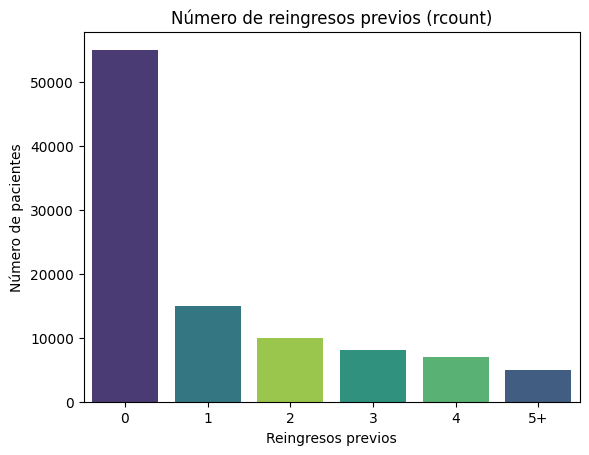

In [9]:
# Gráfico de barras: número de reingresos (rcount) ordenado
orden_rcount = ["0", "1", "2", "3", "4", "5+"]
sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='rcount', palette='viridis', legend=False)
plt.title("Número de reingresos previos (rcount)")
plt.xlabel("Reingresos previos")
plt.ylabel("Número de pacientes")
plt.show()